# EV Charging Infrastructure in NSW - Key Findings


1. EV Adoption is still in its Early Stages

NSW has 306,992 registered eletric vehicles, representing only 1.03% of all 29.7 million registered vehicles.Petrol vehicles still dominates at 67% and diesel 28%. Fully eletric vehicles still have a long way to go before mainstream adoption.

Important: This number is likely a significant undercount. See Data Limitations later on.

What the government should do:
- Introduce purchase incentives to make EVs more affordable.
- Invest in public awareness campaigns to educate drivers about EV benefits and runnins costs.




2. Tesla Domiantes both sides of the Market
Tesla both owns  more than 50% of all registered EVs and controls more than 230 stations. BYD and Polestar are emerging  but remain far behind.

What the govenment should do:
- Encorage more competition by supporting other operators. Avoid over reliance on a single private operator.
- Require Interoperability standars - All chargers should work with all EVs regardless of brand.





3. Infrastructure is Critically Undersized
NSW has 1243 active charging stations with 3,327 plugs, averaging 2.7 plugs per station.This means that 92 EVs compete for every single charging plug across NSW. Most stations are small AC chargers designed for slor overnight charging rather than fast DC charging.

What the government should do:
- Mandate minimum charging requiriments in new shoppings, apartments buildings and workplaces.
- Increase the number of DC fast chargers. DCs stations as minority.
- Fund largers stations with more plugs rather than small single plug stations.
- Target a ratio of no more than 20 EVs per plug to match other countries.





4. Supply and Demand are Geographically Misaligned
The areas with the most EVs are not always the areas with the most charging stations:
- Sydney and The Hills  are outliers but they are still the most underserved. Both above 270 Evs per plug. Highway towns like Port Macquarie and Cessnock have many station but few EVs (built for travellers, not residents).
- Conduct demand based infrastructure planning: Build chargers where EVs are needed.
- Prioritize regions that have more pressure.
- Develop a highway charging corridor strategy connecting all major NSW cities with DC fasrt chargers.





5. Wealth is the strongest predictor of EV Ownership
- Using the IRSAD socioeconomic index:
The Wealthiest areas (decile 10) have almost 90 x more EVs than the most disadvantage areas (decile 1).
- Cost remains the biggest barrier to EV adoption in disadvantaged communities.

What the government should do:
- Introduce subsidies for lower income houselholds.
- Work with employers to offer salary sacrifice EV schemes , making EVs accessible to middle and low income workers.
- Invest in electric public transport in disadvantaged area as an alternative  plan to private EV ownership.





6. The Paradox:
The most surprising findings is that wealthy areas face the most charging pressure despite having the most infrastrucutre. EV ownersip is so heabvily concentrated in wealthy areas that even their largers infrastrucuture cant keep up.







IMPORTANT:

DATA LIMITATIONS

 Dataset only covers postcodes with charging stations:
 This analysis covers postcode that already have charging stations. Postcodes without any stations are completely invisible in our data, meaning the most underserved areas are likely not even represented in this analysis. Therefore, some populated suburbs are missing from the dataset.



=== NSW DATASET SUMMARY ===

Total rows:           1906160


Total vehicles:       29774810


Unique postcodes:     371


Unique stations:      1430


Active stations:      1243


Upcoming stations:    187


Total EVs:            306992


EV % of all vehicles: 1.03 %

# Assignment 2 - EDA

# 1) Importing Pandas Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2.0) Understanding the Dataset's Fundamentals

## 2.1) Importing Dataset and analysing

Thom's File Location

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/DVN/DVN Assignment 3 Datasets/Datasets and EDA - Thom/EDA/Combined_Updated.csv')

Shivom's File Location

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Combined_Updated.csv')

/tmp/ipykernel_10986/2157873388.py:1: DtypeWarning: Columns (0,8,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Combined_Updated.csv')


In [ ]:
# Verifying states
df['state_abb'].value_counts(dropna=False)

,count
state_abb,
NSW,1906762
Vic,48788
Qld,39044
ACT,19882
SA,14918
Tas,4802
WA,216
NT,40
-,2


In [ ]:
# Filter to NSW only
df = df[df['state_abb'] == 'NSW']
print('Shape after filtering to NSW only:', df.shape)
print()
print('States Available')
print(df['state_abb'].value_counts())


Shape after filtering to NSW only: (1906762, 31)

States Available
state_abb
NSW    1906762
Name: count, dtype: int64


In [ ]:
df['registered_postcode'].nunique()

371

1,906,762 rows for NSW.

In [ ]:
# Displaying all columns
pd.set_option('display.max_columns', None)
df

,OBJECTID,Station_name,Station_address,Opening_hours,Operator,Number_of_stations,Number_of_plugs,Charger_type,Charger_rating,Tesla_Fast,Latitude,Longitude,LGANAME,PCODE,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,2021 Postal Area (POA) Code,IRSD Score,IRSD Decile,IRSAD Score,IRSAD Decile,IER Score,IER Decile,IEO Score,IEO Decile,Usual Resident Population
0,546,Darling Quarter First Parking,"1/11 Harbour St, Sydney NSW 2000, Australia",NaN,NaN,2.0,2,AC,NaN,0.0,-33.874400,151.202559,SYDNEY,2000.0,Passenger vehicles,NSW,2000.0,Petrol,BMW,230,7,2000.0,973.065405,4,1106.973326,10,804.156377,1,1142.271453,10.0,27936.0
1,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",NaN,NaN,1.0,1,AC,NaN,0.0,-33.863851,151.202139,SYDNEY,2000.0,Motorcycles,NSW,2000.0,Petrol,YAMAHA,YZF-R6,4,2000.0,973.065405,4,1106.973326,10,804.156377,1,1142.271453,10.0,27936.0
2,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",NaN,NaN,1.0,1,AC,NaN,0.0,-33.863851,151.202139,SYDNEY,2000.0,Motorcycles,NSW,2000.0,Petrol,YAMAHA,YZF155,0,2000.0,973.065405,4,1106.973326,10,804.156377,1,1142.271453,10.0,27936.0
3,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",NaN,NaN,1.0,1,AC,NaN,0.0,-33.863851,151.202139,SYDNEY,2000.0,Motorcycles,NSW,2000.0,Petrol,YAMAHA,YZF320,3,2000.0,973.065405,4,1106.973326,10,804.156377,1,1142.271453,10.0,27936.0
4,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",NaN,NaN,1.0,1,AC,NaN,0.0,-33.863851,151.202139,SYDNEY,2000.0,Motorcycles,NSW,2000.0,Petrol,YAMAHA,YZR-R7,3,2000.0,973.065405,4,1106.973326,10,804.156377,1,1142.271453,10.0,27936.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034279,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,XV1000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2034280,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,YZF-R1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2034281,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,YZF-R1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2034282,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Battery/Fuel-cell electric,FONZARELLI,UNKNOWN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Verifying the shape
print("Rows: ", df.shape[0] )
print("Columns: ", df.shape[1])

Rows:  1906762
Columns:  31


In [ ]:
# Verifying all columns
print(df.columns.tolist())

['OBJECTID', 'Station_name', 'Station_address', 'Opening_hours', 'Operator', 'Number_of_stations', 'Number_of_plugs', 'Charger_type', 'Charger_rating', 'Tesla_Fast', 'Latitude', 'Longitude', 'LGANAME', 'PCODE', 'vehicle_type', 'state_abb', 'registered_postcode', 'motive_power', 'make', 'model', 'no_vehicles', '2021 Postal Area (POA) Code', 'IRSD Score', 'IRSD Decile', 'IRSAD Score', 'IRSAD Decile', 'IER Score', 'IER Decile', 'IEO Score', 'IEO Decile', 'Usual Resident Population']


In [ ]:
# Clean all column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [ ]:
df.columns.tolist()

['objectid',
 'station_name',
 'station_address',
 'opening_hours',
 'operator',
 'number_of_stations',
 'number_of_plugs',
 'charger_type',
 'charger_rating',
 'tesla_fast',
 'latitude',
 'longitude',
 'lganame',
 'pcode',
 'vehicle_type',
 'state_abb',
 'registered_postcode',
 'motive_power',
 'make',
 'model',
 'no_vehicles',
 '2021_postal_area_(poa)_code',
 'irsd_score',
 'irsd_decile',
 'irsad_score',
 'irsad_decile',
 'ier_score',
 'ier_decile',
 'ieo_score',
 'ieo_decile',
 'usual_resident_population']

In [ ]:
# Renaming columns
df = df.rename(columns={'2021_postal_area_(poa)_code':'poa_code',
                        'usual_resident_population':'population'
})

In [ ]:
df.columns.tolist()

['objectid',
 'station_name',
 'station_address',
 'opening_hours',
 'operator',
 'number_of_stations',
 'number_of_plugs',
 'charger_type',
 'charger_rating',
 'tesla_fast',
 'latitude',
 'longitude',
 'lganame',
 'pcode',
 'vehicle_type',
 'state_abb',
 'registered_postcode',
 'motive_power',
 'make',
 'model',
 'no_vehicles',
 'poa_code',
 'irsd_score',
 'irsd_decile',
 'irsad_score',
 'irsad_decile',
 'ier_score',
 'ier_decile',
 'ieo_score',
 'ieo_decile',
 'population']

In [ ]:
print(df.dtypes)

objectid                object
station_name            object
station_address         object
opening_hours           object
operator                object
number_of_stations     float64
number_of_plugs          int64
charger_type            object
charger_rating          object
tesla_fast             float64
latitude               float64
longitude              float64
lganame                 object
pcode                  float64
vehicle_type            object
state_abb               object
registered_postcode    float64
motive_power            object
make                    object
model                   object
no_vehicles              int64
poa_code               float64
irsd_score              object
irsd_decile             object
irsad_score             object
irsad_decile            object
ier_score               object
ier_decile              object
ieo_score              float64
ieo_decile             float64
population             float64
dtype: object


Formatting dtype for Numerical Features. The scores are stored as text, they should be numbers.

In [ ]:
cols_to_fix = ['charger_rating', 'irsd_score','irsd_decile','irsad_score','irsad_decile','ier_score','ier_decile']

In [ ]:
for col in cols_to_fix:
  df[col] = pd.to_numeric(df[col], errors = 'coerce')

In [ ]:
print(df[cols_to_fix].dtypes)

charger_rating    float64
irsd_score        float64
irsd_decile       float64
irsad_score       float64
irsad_decile      float64
ier_score         float64
ier_decile        float64
dtype: object


columns are numbers type now.

#

In [ ]:
# Verifying Null Values
print(df.isnull().sum())

objectid                    0
station_name           254540
station_address             0
opening_hours          798435
operator               441231
number_of_stations     254540
number_of_plugs             0
charger_type                0
charger_rating         784031
tesla_fast             254540
latitude                    0
longitude                   0
lganame                     0
pcode                    1204
vehicle_type                0
state_abb                   0
registered_postcode      1204
motive_power                0
make                        0
model                       0
no_vehicles                 0
poa_code                 1204
irsd_score               1257
irsd_decile              1257
irsad_score              1257
irsad_decile             1257
ier_score                1257
ier_decile               1257
ieo_score                1204
ieo_decile               1204
population               1204
dtype: int64


In [ ]:
# Verifying all missing values as %.
missing = (df.isnull().sum()/len(df)*100).round(1)

In [ ]:
missing

,0
objectid,0.0
station_name,13.3
station_address,0.0
opening_hours,41.9
operator,23.1
number_of_stations,13.3
number_of_plugs,0.0
charger_type,0.0
charger_rating,41.1
tesla_fast,13.3


In [ ]:
missing = missing[missing > 0 ].sort_values(ascending=True)
missing

,0
pcode,0.1
registered_postcode,0.1
ier_score,0.1
irsad_decile,0.1
irsad_score,0.1
irsd_decile,0.1
irsd_score,0.1
poa_code,0.1
ier_decile,0.1
ieo_score,0.1


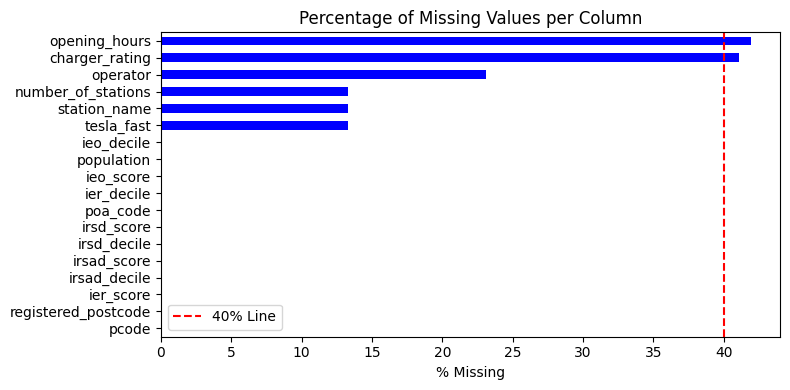

In [ ]:
# Plotting missing values
missing.plot(kind='barh', color='blue', figsize=(8,4))
plt.title('Percentage of Missing Values per Column')
plt.xlabel('% Missing')
plt.axvline(x=40, color='red', linestyle='--', label = '40% Line')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Verifying opening hours.
df['opening_hours'].value_counts()

,count
opening_hours,
Open 24/7,824548
Business hours,5175
During Business Hours,3921
6:00 AM - 12:00 AM,3690
Mon - Sat 5:30AM - 12:30AM Sun & public holidays 6:30AM - 12:30AM,3240
...,...
By Appointment,392
9 am to 9 pm,387
Phone ahead to confirm,199


In [ ]:
# Opening hours is a mess. Maybe I will exclude this feature or not analyze it. The way it is right now, it will not help our analysis.
df['opening_hours'] = df['opening_hours'].fillna('Unknown')
print(df['opening_hours'].isnull().sum())
print(df['opening_hours'].value_counts().head(10))

0
opening_hours
Open 24/7                                                            824548
Unknown                                                              798435
Business hours                                                         5175
During Business Hours                                                  3921
6:00 AM - 12:00 AM                                                     3690
Mon - Sat 5:30AM - 12:30AM Sun & public holidays 6:30AM - 12:30AM      3240
7:00 AM - 10:00 PM                                                     3131
10am to 10pm                                                           2837
Closes 6pm                                                             2694
5am - 11:30pm                                                          2390
Name: count, dtype: int64


In [ ]:
test_cols = ['station_name','operator','opening_hours']

In [ ]:
for col in test_cols:
  df[col] = df[col].fillna('Unknown')


print(df[['station_name','operator','opening_hours']].isnull().sum())

station_name     0
operator         0
opening_hours    0
dtype: int64


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

number_of_stations     254540
charger_rating         784031
tesla_fast             254540
pcode                    1204
registered_postcode      1204
poa_code                 1204
irsd_score               1257
irsd_decile              1257
irsad_score              1257
irsad_decile             1257
ier_score                1257
ier_decile               1257
ieo_score                1204
ieo_decile               1204
population               1204
dtype: int64


There are only numerical features missing values now. I will leave for now nan for numerical columns because I dont want to invent numbers.

In [ ]:
# Verifying duplicated rows.
print('Duplicated rows: ', df.duplicated().sum())

Duplicated rows:  602


In [ ]:
df[df.duplicated()]

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population
2031755,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Passenger vehicles,NSW,NaN,Petrol,ALFA ROMEO,GIULIA,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2031757,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Passenger vehicles,NSW,NaN,Petrol,ALFA ROMEO,GIULIETTA,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2031759,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Passenger vehicles,NSW,NaN,Petrol,ALPINE,A110,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2031761,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Passenger vehicles,NSW,NaN,Petrol,ASTON MARTIN,RAPIDE,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2031763,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Passenger vehicles,NSW,NaN,Petrol,ASTON MARTIN,VANTAGE,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034275,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,WR450,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2034277,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,XT1200,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2034279,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,XV1000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2034281,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,PORT STEPHENS,NaN,Motorcycles,NSW,NaN,Petrol,YAMAHA,YZF-R1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Dropping the duplicated rows
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print('Duplicated rows after cleaning:', df.duplicated().sum())
print('New Shape: ', df.shape)

Duplicated rows after cleaning: 0
New Shape:  (1906160, 31)


There no more duplications.

In [ ]:
# Checking if coordinates make sense
bad_coords = df[
    (df['latitude']  < -38) | (df['latitude']  > -28) |
    (df['longitude'] < 140) | (df['longitude'] > 154)
]

print("Rows with suspicious coordinates:", len(bad_coords))

Rows with suspicious coordinates: 0


In [ ]:
print("Latitude  — min:", df['latitude'].min(),  " max:", df['latitude'].max())
print("Longitude — min:", df['longitude'].min(), " max:", df['longitude'].max())

Latitude  — min: -37.1032  max: -28.16865631
Longitude — min: 141.445388  max: 153.620656


Coordinates seems correct.

In [ ]:
# Cleaning text values
text_cols = ['station_name', 'operator', 'charger_type',
             'vehicle_type', 'motive_power', 'make', 'lganame']

for col in text_cols:
    df[col] = df[col].str.title().str.strip()

In [ ]:
print("Charger types:\n",  df['charger_type'].unique())
print("\nMotive power:\n",  df['motive_power'].unique())
print("\nVehicle types:\n", df['vehicle_type'].unique())

Charger types:
 ['Ac' 'Upcoming' 'Dc']

Motive power:
 ['Petrol' 'Battery/Fuel-Cell Electric' 'Diesel' 'Dual Fuel'
 'Hybrid Electric' 'Other']

Vehicle types:
 ['Passenger Vehicles' 'Motorcycles' 'Light Rigid Trucks'
 'Heavy Rigid Trucks' 'Light Commercial Vehicles' 'Campervans'
 'Light Buses' 'Heavy Buses' 'Non-Freight-Carrying Vehicles'
 'Articulated Trucks']


In [ ]:
df['charger_type'] = df['charger_type'].replace({
    'Ac': 'AC',
    'Dc': 'DC'
})

In [ ]:
print("Charger types:", df['charger_type'].unique())

Charger types: ['AC' 'Upcoming' 'DC']


In [ ]:
df['motive_power'] = df['motive_power'].replace({'-': 'Unknown'})

print("Motive power:", df['motive_power'].unique())

Motive power: ['Petrol' 'Battery/Fuel-Cell Electric' 'Diesel' 'Dual Fuel'
 'Hybrid Electric' 'Other']


In [ ]:
df['motive_power'].value_counts()

,count
motive_power,
Petrol,1232116
Diesel,526927
Hybrid Electric,70357
Battery/Fuel-Cell Electric,38406
Dual Fuel,29978
Other,8376


In [ ]:
print("Shape:", df.shape)
print()
print("Missing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (1906160, 31)

Missing values remaining:
number_of_stations     254540
charger_rating         784031
tesla_fast             254540
pcode                     602
registered_postcode       602
poa_code                  602
irsd_score                655
irsd_decile               655
irsad_score               655
irsad_decile              655
ier_score                 655
ier_decile                655
ieo_score                 602
ieo_decile                602
population                602
dtype: int64


number_of_station, tesla_fast : Not all vehicles rows have a matching station.
charger_rating : 41% of station never recorded their kW rating.

In [ ]:
df.head()

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population
0,546,Darling Quarter First Parking,"1/11 Harbour St, Sydney NSW 2000, Australia",Unknown,Unknown,2.0,2,AC,NaN,0.0,-33.874400,151.202559,Sydney,2000.0,Passenger Vehicles,NSW,2000.0,Petrol,Bmw,230,7,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
1,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Petrol,Yamaha,YZF-R6,4,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
2,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Petrol,Yamaha,YZF155,0,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
3,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Petrol,Yamaha,YZF320,3,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
4,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Petrol,Yamaha,YZR-R7,3,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0


In [ ]:
# Fixing car make capitalisation
# List of makes that should be fully uppercase
uppercase_makes = ['Bmw', 'Mg', 'Lti', 'Ldv', 'Byd', 'Gmc',
                   'Kia', 'Bmw', 'Vw', 'Suv']

for make in uppercase_makes:
    df['make'] = df['make'].replace(make, make.upper())

# Check how the top makes look now
print(df['make'].value_counts().head(20))

make
Mercedes-Benz    174210
Toyota           121499
BMW              107831
Honda             87510
Ford              76561
Holden            76074
Yamaha            57323
Suzuki            57216
Mazda             54790
Nissan            53497
Volkswagen        51869
Hyundai           51763
Mitsubishi        49150
Lexus             46095
Isuzu             43820
Audi              43247
Volvo             38108
Kawasaki          36716
KIA               30495
Peugeot           26796
Name: count, dtype: int64


In [ ]:
# verifying Unique Stations and total vehicle records.
unique_stations = df.drop_duplicates('objectid')
print('Unique charging stations: ', len(unique_stations))

print('Total vehicle records:', len(df))

Unique charging stations:  1430
Total vehicle records: 1906160


In [ ]:
# Understanding what each row actually represents by looking at what makes each row unique

print(('Total rows:', len(df)))
print()

# Checking if some make, model and postcode combination repeats
print("Unique combinations of postcode + make + model:")
print(df[['registered_postcode', 'make', 'model']].drop_duplicates().shape[0])
print()

# Looking at what no_vehicles column actually means
print("Sample of no_vehicles column:")
print(df[['registered_postcode', 'make', 'model', 'no_vehicles']].head(10))

('Total rows:', 1906160)

Unique combinations of postcode + make + model:
325855

Sample of no_vehicles column:
   registered_postcode              make    model  no_vehicles
0               2000.0               BMW      230            7
1               2000.0            Yamaha   YZF-R6            4
2               2000.0            Yamaha   YZF155            0
3               2000.0            Yamaha   YZF320            3
4               2000.0            Yamaha   YZR-R7            3
5               2000.0         Zhongneng  UNKNOWN            3
6               2000.0              Znen  UNKNOWN            0
7               2000.0               BMW     CE04            0
8               2000.0        Fonzarelli  UNKNOWN            5
9               2000.0  Fonzarelli Bikes  UNKNOWN            0


There are 7 BMWs Model 230 in postcode 2000.

In [ ]:
# Total number of registered vehicles across all postcodes
total_vehicles = df['no_vehicles'].sum()
print('Total registered vehicles:', total_vehicles)

# Vehicles per postcode on average

total_postcodes = df['registered_postcode'].nunique()
print('Unique postocdes', total_postcodes)
print('Average vehicles per postcode: ', round(total_vehicles/total_postcodes))

Total registered vehicles: 29774810
Unique postocdes 371
Average vehicles per postcode:  80256


- 29 million vehicles registered across NSW
- 371 unique postcodes
- +- 80,256 Vehicles per postcode on average

That makes sense for NSW. It is a large state with many registered vehicles


In [ ]:
print("Total vehicles:  ", df['no_vehicles'].sum())
print("Unique postcodes:", df['registered_postcode'].nunique())
print()

# Check if the bad total row is still there
print("Any 'Total' vehicle type rows?")
print(df[df['vehicle_type'] == 'Total'].shape[0])

Total vehicles:   29774810
Unique postcodes: 371

Any 'Total' vehicle type rows?
0


In [ ]:
# Sydney Example:
postcode_2000 = df[df['registered_postcode']== 2000]

print('Rows for postcode 2000:' , len(postcode_2000))
print('Total vehicles in postcode 2000:', postcode_2000['no_vehicles'].sum())

Rows for postcode 2000: 52470
Total vehicles in postcode 2000: 1134342


In Sydney, There are 52,470 rows combining make and model.There are 1,134,342 actual vehicles

# 3) DEA

In [ ]:
# Verifying Charger Types
charger_counts = unique_stations['charger_type'].value_counts()
print(charger_counts)

charger_type
AC          989
DC          254
Upcoming    187
Name: count, dtype: int64


AC Chargers are the most common, but they are slower chargers. DC chargers are lescc common, they are faster chargers. There are 187 statios planned but not build yet.

- AC Chargers can take between 6 and 12 hours to fully charge a car. Good for destinantion charging (hotels, shoppings, offices).
- DC Chargers take betwen 20 to 60 minutes to fully charge. Best for highway stops and busy locations. Important for longo distance travel.

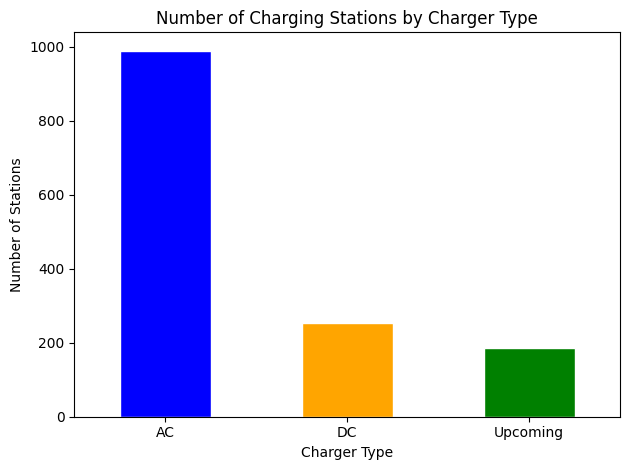

In [ ]:
# Plotting bar chart
charger_counts.plot(kind='bar',
                    color=['blue', 'orange', 'green'],
                    edgecolor='white')

plt.title('Number of Charging Stations by Charger Type')
plt.xlabel('Charger Type')
plt.ylabel('Number of Stations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Verifying Upcoming Stations if they are indeed stations that are being built.
upcoming = unique_stations[unique_stations['charger_type'] == 'Upcoming']
print(upcoming[['station_name', 'station_address', 'operator',
                'number_of_plugs', 'charger_rating']].head(10))

       station_name                                    station_address  \
74680       Unknown  49-59 O'Riordan St, Alexandria NSW 2015, Austr...   
81915       Unknown        2 Central Ave, Eveleigh NSW 2015, Australia   
90783       Unknown  867-869 South Dowling St, Waterloo NSW 2017, A...   
121607      Unknown   71 Spring St, Bondi Junction NSW 2022, Australia   
137465      Unknown        Campbell Pde Bondi Beach NSW 2026 Australia   
154284      Unknown  235 New South Head Rd, Edgecliff NSW 2027, Aus...   
165260      Unknown          2 Alison Rd, Randwick NSW 2031, Australia   
173674      Unknown     48 Gardeners Rd, Kingsford NSW 2032, Australia   
182522      Unknown        737 Anzac Pde, Maroubra NSW 2035, Australia   
190921      Unknown  238-262 Bunnerong Rd, Hillsdale NSW 2036, Aust...   

                                     operator  number_of_plugs  charger_rating  
74680         Tesla Motors Australia, Pty Ltd                6             NaN  
81915         Tesla Mot

In [ ]:
print(upcoming['charger_rating'].value_counts(dropna=False))

charger_rating
NaN    187
Name: count, dtype: int64


There are 187 upcoming stations and all of them have no charger_rating, meaning they are not operational yet.

In [ ]:
# Do they have operators?
print(upcoming['operator'].value_counts().head(10))

operator
Fast Cities Australia (Evie Networks)    35
Tesla Motors Australia, Pty Ltd          32
Viva Energy                              30
Ampol Australia Energy Pty Ltd           19
Bp                                       17
Bp Australia Pty Ltd                     16
Nrma                                     15
Ampcharge                                 7
Tesla                                     7
Fast Cities Australia Pty Ltd             7
Name: count, dtype: int64


In [ ]:
upcoming['operator'].value_counts().sum()

np.int64(187)

Upcoming Stations: They are already planned and they are assigned to an operator but they are not yet operational.

In [ ]:
# Do AC Stations have charger rating?
ac_stations = unique_stations[unique_stations['charger_type'] == 'AC']
print("AC stations with a charger rating:")
print(ac_stations['charger_rating'].value_counts(dropna=False).head())

AC stations with a charger rating:
charger_rating
22.0    394
NaN     366
7.0     126
11.0     24
6.0      19
Name: count, dtype: int64


394 stations have a rating of 22 kw, 366 have no rating, so real stations are missing this data too. It explains why charger_rating has 41% missing values.

In [ ]:
# Separating active stations from upcoming stations:
active_stations = unique_stations[unique_stations['charger_type'] != 'Upcoming']

print("Active stations:", len(active_stations))
print("Upcoming stations:", len(unique_stations[unique_stations['charger_type'] == 'Upcoming']))
print("Total stations:", len(unique_stations))

Active stations: 1243
Upcoming stations: 187
Total stations: 1430


In [ ]:
# Checking Station Capacity for Active Stations: How many plugs per station?
plugs_by_type = active_stations.groupby('charger_type')['number_of_plugs'].mean().round(1)
print(plugs_by_type)

charger_type
AC    2.4
DC    3.7
Name: number_of_plugs, dtype: float64


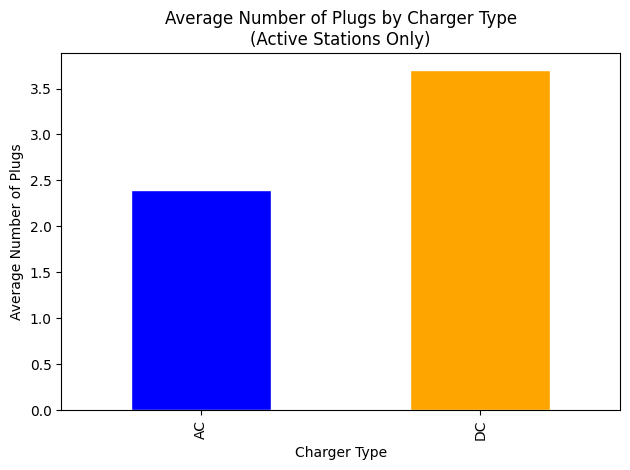

In [ ]:
plugs_by_type.plot(kind='bar',
                   color=['blue', 'orange'],
                   edgecolor='white')

plt.title('Average Number of Plugs by Charger Type\n(Active Stations Only)')
plt.xlabel('Charger Type')
plt.ylabel('Average Number of Plugs')
plt.tight_layout()
plt.show()

On average, DC stations have more plugs because they are fasters hubs. This makes sense since DC stations are build at busy locations like highways and busy centers where many cars need to charge quickly and at the same time.

Verify how AC and DC are spread across NSW on tableau.

## Which operator has the most stations?

In [ ]:
top_operators = (active_stations['operator'].value_counts().head(10))
print(top_operators)

operator
Unknown              329
Tesla Destination    199
Exploren             197
Chargefox            173
Nrma                  59
Evie Networks         51
Jolt                  37
Tesla Supercharge     30
Bp Pulse              24
Evup                  21
Name: count, dtype: int64


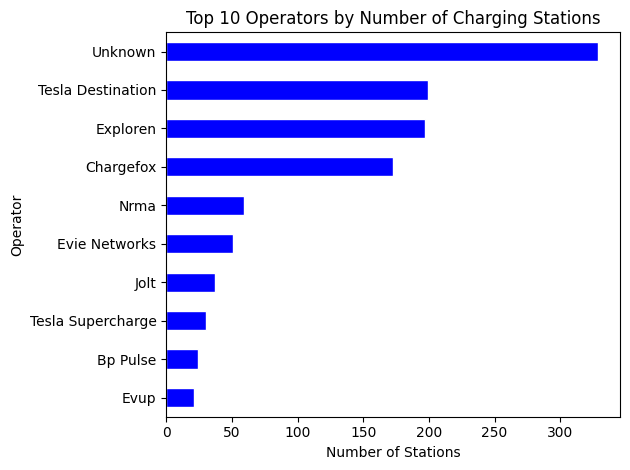

In [ ]:
top_operators.plot(kind='barh',
                   color='blue',
                   edgecolor='white')
plt.title('Top 10 Operators by Number of Charging Stations')
plt.xlabel('Number of Stations')
plt.ylabel('Operator')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

There are 329 Unknown stations, the data has many gaps. There are 2 entries for tesla, I will change that.

In [ ]:
df['operator'] = df['operator'].replace({
    'Tesla Destination'  : 'Tesla',
    'Tesla Supercharge'  : 'Tesla',
    'Tesla Supercharger' : 'Tesla'
})

unique_stations['operator'] = unique_stations['operator'].replace({
    'Tesla Destination'  : 'Tesla',
    'Tesla Supercharge'  : 'Tesla',
    'Tesla Supercharger' : 'Tesla'
})

active_stations['operator'] = active_stations['operator'].replace({
    'Tesla Destination'  : 'Tesla',
    'Tesla Supercharge'  : 'Tesla',
    'Tesla Supercharger' : 'Tesla'
})

print("Tesla entries fixed.")

Tesla entries fixed.


/tmp/ipykernel_10986/840262160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_stations['operator'] = unique_stations['operator'].replace({
/tmp/ipykernel_10986/840262160.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_stations['operator'] = active_stations['operator'].replace({


In [ ]:
top_operators = (active_stations[active_stations['operator'] != 'Unknown']['operator'].value_counts().head(10))
print(top_operators)

operator
Tesla            230
Exploren         197
Chargefox        173
Nrma              59
Evie Networks     51
Jolt              37
Bp Pulse          24
Evup              21
Everty            20
Evx               20
Name: count, dtype: int64


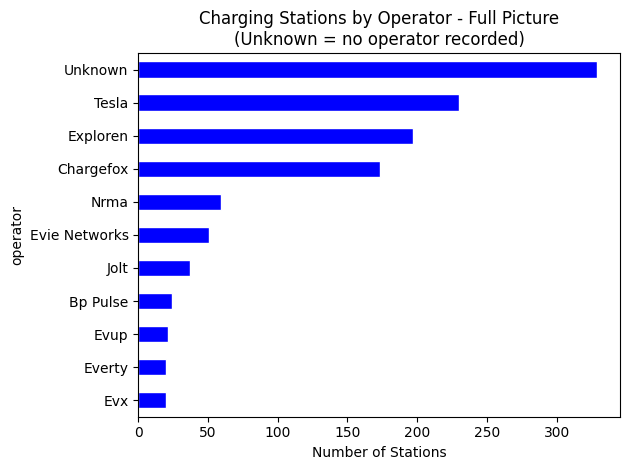

In [ ]:
# Full picture INCLUDING Unknown
all_operators = (active_stations['operator']
                 .value_counts()
                 .head(11))

all_operators.plot(kind='barh',
                   color='blue',
                   edgecolor='white')

plt.title('Charging Stations by Operator - Full Picture\n(Unknown = no operator recorded)')
plt.xlabel('Number of Stations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Tesla, Exploren, Chargefox are the biggest operators. Unknown is still a data quality issue.

In [ ]:
# Vehicle Analysis: Petrol Vs Eletric
# Using Full df and sum_no_vehicles
vehicles_by_power = df.groupby('motive_power')['no_vehicles'].sum().sort_values(ascending=False)
print(vehicles_by_power)

motive_power
Petrol                        20175548
Diesel                         8292246
Hybrid Electric                 895304
Battery/Fuel-Cell Electric      306992
Dual Fuel                        59955
Other                            44765
Name: no_vehicles, dtype: int64


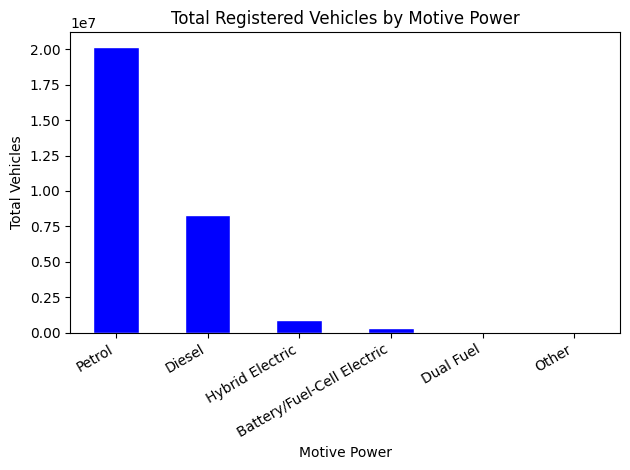

In [ ]:
vehicles_by_power.plot(kind='bar',
                       color='blue',
                       edgecolor='white')

plt.title('Total Registered Vehicles by Motive Power')
plt.xlabel('Motive Power')
plt.ylabel('Total Vehicles')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Why so many Unknown?

In [ ]:
unknown_power = df[df['motive_power']== 'Unknown']
print(unknown_power['vehicle_type'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
# Checking states that have the most unknown
print(unknown_power['state_abb'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
unknown_power = df[df['motive_power'] == 'Unknown']
print(unknown_power[['registered_postcode', 'vehicle_type',
                      'state_abb', 'make', 'model', 'no_vehicles']])

Empty DataFrame
Columns: [registered_postcode, vehicle_type, state_abb, make, model, no_vehicles]
Index: []


In [ ]:
unknown_power

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population


In [ ]:
df[df['motive_power']=='Unknown']

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population


In [ ]:
df[df['vehicle_type']=='Total']

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population


This is a grand total row that was accidentally included in the dataset. It is like the last row that sums everything up. It means our total of 2 million vehicles was wrong. The total should be 52,038,280 - 21,736,966 = 30,301,314 real vehicles.

I will remove it.

In [ ]:
df = df[df['vehicle_type']!= 'Total']

In [ ]:
print("Rows after removing total row:", len(df))
print()

Rows after removing total row: 1906160



In [ ]:
print("Real total registered vehicles:", df['no_vehicles'].sum())

Real total registered vehicles: 29774810


## Redoing vehicles by motive power

In [ ]:
vehicles_by_power = df.groupby('motive_power')['no_vehicles'].sum().sort_values(ascending=False)
print(vehicles_by_power)

motive_power
Petrol                        20175548
Diesel                         8292246
Hybrid Electric                 895304
Battery/Fuel-Cell Electric      306992
Dual Fuel                        59955
Other                            44765
Name: no_vehicles, dtype: int64


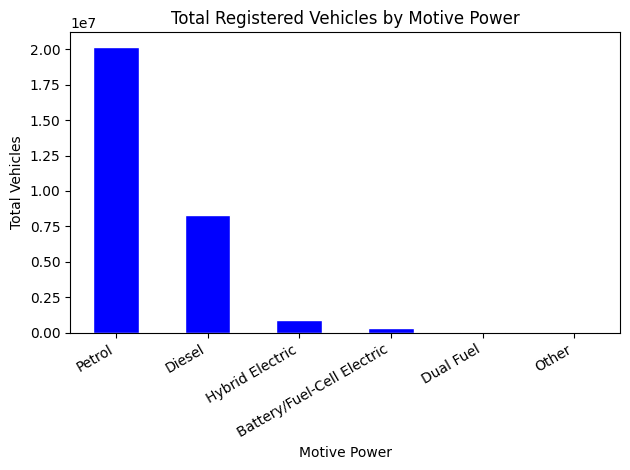

In [ ]:
vehicles_by_power.plot(kind='bar',
                       color='blue',
                       edgecolor='white')

plt.title('Total Registered Vehicles by Motive Power')
plt.xlabel('Motive Power')
plt.ylabel('Total Vehicles')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Most vehicles are either petrol or diesel. NSW is still heavily dependent on fossil fuels only.

In [ ]:
total_evs = df[df['motive_power']=='Battery/Fuel-Cell Electric']['no_vehicles'].sum()
total_evs

np.int64(306992)

In [ ]:
total_active_stations = len(active_stations)
total_active_stations

1243

In [ ]:
evs_per_station = round(total_evs/ total_active_stations)

In [ ]:
print("Total EVs in NSW:          ", total_evs)
print("Total active stations:     ", total_active_stations)
print("EVs per charging station:  ", evs_per_station)
print()

# calculate plugs
total_plugs = active_stations['number_of_plugs'].sum()
evs_per_plug = round(total_evs / total_plugs)
print("Total plugs available:     ", int(total_plugs))
print("EVs per plug:              ", evs_per_plug)

Total EVs in NSW:           306992
Total active stations:      1243
EVs per charging station:   247

Total plugs available:      3327
EVs per plug:               92


92 Evs per plug seems high! If the population of battery vehicles increase and the number of stations don't increase, NSW might have a problem on a near future.



In [ ]:
print('DATASET SUMMARY')
print('Unique charging stations',   len(unique_stations))
print('Active charging stations',   len(active_stations))
print('Unique postcodes:'       ,   df['registered_postcode'].nunique())
print('Total registered vehicles:', df['no_vehicles'].sum())
print('Total rows in dataset:',     len(df))

DATASET SUMMARY
Unique charging stations 1430
Active charging stations 1243
Unique postcodes: 371
Total registered vehicles: 29774810
Total rows in dataset: 1906160


## Top EV Makes

In [ ]:
# Filtering to only count eletric vehicles
evs_only = df[df['motive_power']=='Battery/Fuel-Cell Electric']

# Coun total EVs per make
top_ev_makes = (evs_only.groupby('make')['no_vehicles'].sum().sort_values(ascending=False).head(10))
print(top_ev_makes)

make
Tesla            162445
BYD               24639
Polestar          21241
MG                16507
Hyundai           13283
BMW               11269
KIA                9741
Volvo              9476
Mercedes-Benz      7481
Nissan             4670
Name: no_vehicles, dtype: int64


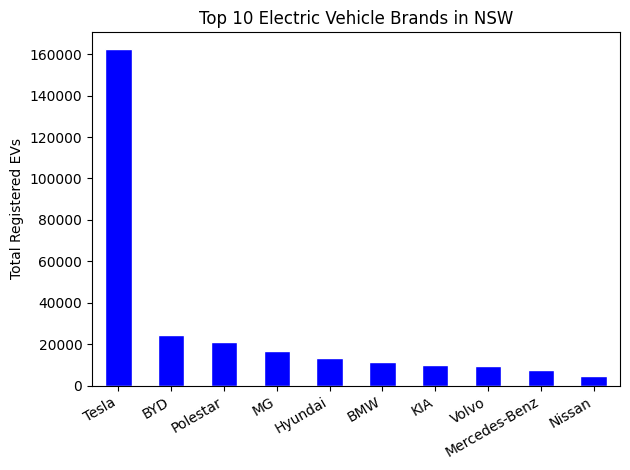

In [ ]:
top_ev_makes.plot(kind='bar',
                  color='blue',
                  edgecolor='white')

plt.title('Top 10 Electric Vehicle Brands in NSW')
plt.xlabel('')
plt.ylabel('Total Registered EVs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Tesla dominates. Tesla has also the most charging stations and we have seen seen earlier. They are contantly building their own network.

## Which areas have the most EVs?

In [ ]:
evs_only

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population
7,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Battery/Fuel-Cell Electric,BMW,CE04,0,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
8,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Battery/Fuel-Cell Electric,Fonzarelli,UNKNOWN,5,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
9,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000.0,Battery/Fuel-Cell Electric,Fonzarelli Bikes,UNKNOWN,0,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
568,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Light Rigid Trucks,NSW,2000.0,Battery/Fuel-Cell Electric,Foton,IBLUE,30,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
569,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Light Rigid Trucks,NSW,2000.0,Battery/Fuel-Cell Electric,LDV,DELIVER 9,0,2000.0,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1905999,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,Port Stephens,NaN,Passenger Vehicles,NSW,NaN,Battery/Fuel-Cell Electric,Tesla,MODEL 3,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1906000,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,Port Stephens,NaN,Passenger Vehicles,NSW,NaN,Battery/Fuel-Cell Electric,Tesla,MODEL Y,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1906001,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,Port Stephens,NaN,Passenger Vehicles,NSW,NaN,Battery/Fuel-Cell Electric,Volvo,C40,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1906002,1179,Soldiers Point Marina,"Sunset Boulevard, Soldiers Point, 2317",Open 24/7,Chargefox,1.0,2,DC,24.0,0.0,-32.701388,152.062646,Port Stephens,NaN,Passenger Vehicles,NSW,NaN,Battery/Fuel-Cell Electric,Volvo,XC40,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
evs_by_lga = evs_only.groupby('lganame')['no_vehicles'].sum().sort_values(ascending=False).head(15)
evs_by_lga

,no_vehicles
lganame,
Sydney,79263
The Hills Shire,19697
Lane Cove,12150
Ryde,11573
Blacktown,10991
Willoughby,10787
Central Coast,9780
Northern Beaches,9091
Bayside,7888


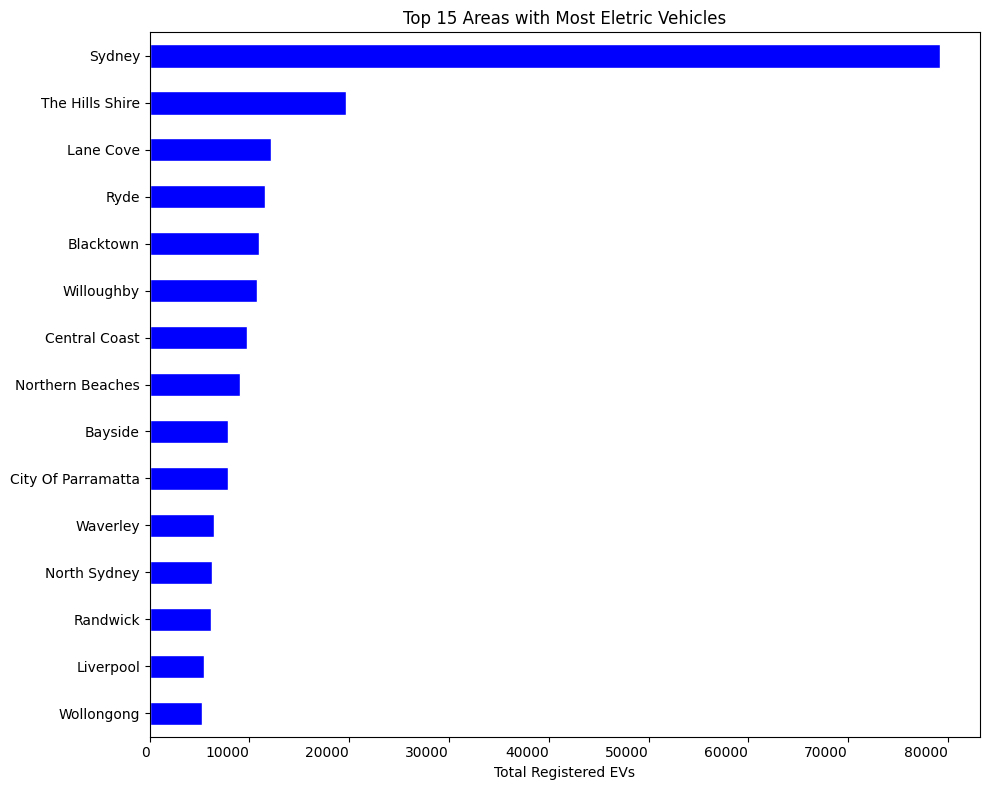

In [ ]:
evs_by_lga.plot(kind='barh',
                  color='blue',
                  edgecolor='white', figsize=(10,8))

plt.title('Top 15 Areas with Most Eletric Vehicles')
plt.xlabel('Total Registered EVs')
plt.ylabel('')
plt.xticks(rotation=0, ha='right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Sydney CBD dominates with ore than 80,000 EVs, 4 times more than the second
place. The Hills Shire, Lane Cove, Ryde, Willoughby — all wealthy northern Sydney suburbs in the top 5 Blacktown is interesting.

EVs seems to be concentrated in wealthier areas.

## Which areas have the most charging stations?

In [ ]:
stations_by_lga = active_stations.groupby('lganame')['objectid'].count().sort_values(ascending=False).head(15)
stations_by_lga

,objectid
lganame,
Sydney,83
Blacktown,43
Northern Beaches,42
City Of Parramatta,33
Central Coast,33
Cessnock,28
Lake Macquarie,28
Shoalhaven,26
Eurobodalla,26


In [ ]:
active_stations['lganame']

,lganame
0,Sydney
1,Sydney
10,Sydney
1622,Sydney
3278,Sydney
...,...
1900870,Broken Hill
1901003,Broken Hill
1902502,Broken Hill
1905538,Tenterfield


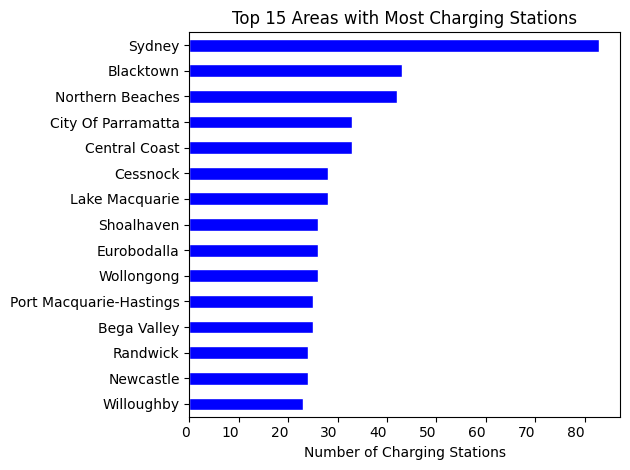

In [ ]:
stations_by_lga.plot(kind='barh',
                  color='blue',
                  edgecolor='white')

plt.title('Top 15 Areas with Most Charging Stations')
plt.xlabel('Number of Charging Stations')
plt.ylabel('')
plt.xticks(rotation=0, ha='right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# EVs and stations together in one tables

# EVs per LGA
evs_lga = (evs_only.groupby('lganame')['no_vehicles'].sum().rename('total_evs'))

# stations per LGA
stations_lga = (active_stations.groupby('lganame')['objectid'].count().rename('total_stations'))

# Combining into one table
comparison = pd.concat([evs_lga, stations_lga], axis=1).fillna(0)

# Calculate EVs per station (higher = mopre underserved)
comparison['evs_per_station'] = (comparison['total_evs'] / comparison['total_stations']).round(0)

# Sort by most EVs
comparison = comparison.sort_values(by='total_evs', ascending=False).head(15)

# Printing the comparison table
print(comparison)

                    total_evs  total_stations  evs_per_station
lganame                                                       
Sydney                79263.0              83            955.0
The Hills Shire       19697.0              21            938.0
Lane Cove             12150.0              22            552.0
Ryde                  11573.0              16            723.0
Blacktown             10991.0              43            256.0
Willoughby            10787.0              23            469.0
Central Coast          9780.0              33            296.0
Northern Beaches       9091.0              42            216.0
Bayside                7888.0              22            359.0
City Of Parramatta     7827.0              33            237.0
Waverley               6417.0              21            306.0
North Sydney           6198.0              13            477.0
Randwick               6095.0              24            254.0
Liverpool              5460.0              13          

- Sydney - Most Pressure. 955 Evs sharing each station. More pressure on infrastructure.
- The Hills Shire and Ryde - Very underserved. Lots of EVs, few stations.
- Wollongong - Best ratio in the top 15.

In [ ]:
evs_lga

,total_evs
lganame,
Albury City,1796
Armidale Regional,476
Ballina,1507
Bathurst Regional,1547
Bayside,7888
...,...
Wingecarribee,2129
Wollondilly,103
Wollongong,5239


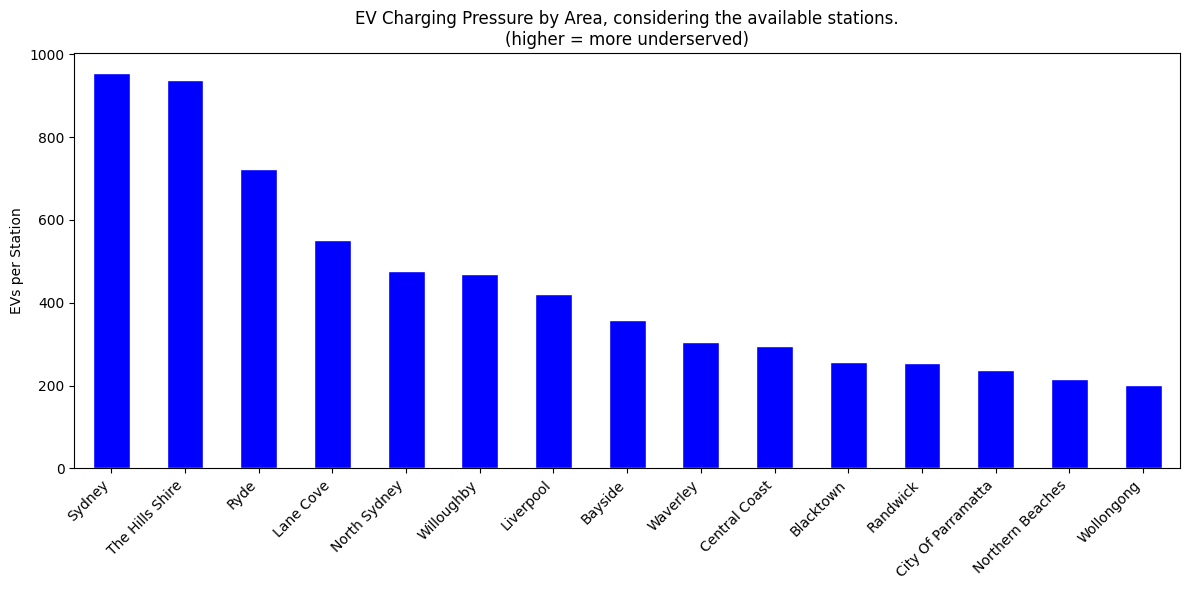

In [ ]:
# EVs per station by area
comparison_sorted = comparison.sort_values('evs_per_station', ascending=False)

comparison_sorted['evs_per_station'].plot(kind='bar',
                                           color='blue',
                                           edgecolor='white',
                                           figsize=(12, 6))

plt.title('EV Charging Pressure by Area, considering the available stations.\n(higher = more underserved)')
plt.xlabel('')
plt.ylabel('EVs per Station')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Story 1 - Sydney has by far the most stations but even Sydney has high pressure ratio -- 955 Evs per station. The infrastrucutre is not keeping up with EV Adoption.

Story 2: The wealthy suburbs are EV hotspots but they are being underserved. The Hills Shire, Lane Cove and Ryde have lots of EVs but few stations.

Story 3: Black Town and Northern Beaches are well balanced, with better planned infrastructure.

Story 4: There is a clear gap between EV adoption and infrastructure.
- Almost every area has far more EVs  than stations.
- As EV adoption grows this gap will get worse. This is an urgent infrastructure planning problem.

While EV adoption is growing rapidly across NSW, particularly in wealthy Sydney suburbs, chargin infrastructure is consistently failing to keep pace, with some areas having over 1000 Evs competing for each charging station.

## Comparison with number of Plugs

In [ ]:
#Calculating again just to make sure the variable captures the correct data
evs_lga  = (evs_only.groupby('lganame')['no_vehicles'].sum().rename('total_evs'))
evs_lga


,total_evs
lganame,
Albury City,1796
Armidale Regional,476
Ballina,1507
Bathurst Regional,1547
Bayside,7888
...,...
Wingecarribee,2129
Wollondilly,103
Wollongong,5239


In [ ]:
plugs_lga = (active_stations.groupby('lganame')['number_of_plugs'].sum().rename('total_plugs'))
plugs_lga

,total_plugs
lganame,
Albury City,54
Armidale Regional,20
Ballina,30
Balranald,4
Bathurst Regional,23
...,...
Wingecarribee,69
Wollondilly,20
Wollongong,65


In [ ]:
evs_vs_plugs = pd.concat([evs_lga, plugs_lga], axis =1).dropna()
evs_vs_plugs

,total_evs,total_plugs
lganame,,
Albury City,1796.0,54
Armidale Regional,476.0,20
Ballina,1507.0,30
Bathurst Regional,1547.0,23
Bayside,7888.0,49
...,...,...
Wingecarribee,2129.0,69
Wollondilly,103.0,20
Wollongong,5239.0,65


In [ ]:
evs_vs_plugs['evs_per_plug'] = (evs_vs_plugs['total_evs'] / evs_vs_plugs['total_plugs']).round(0)
evs_vs_plugs = evs_vs_plugs.sort_values('total_evs', ascending=False).head(15) # before I was filtering per total_evs
print(evs_vs_plugs)

                    total_evs  total_plugs  evs_per_plug
lganame                                                 
Sydney                79263.0          290         273.0
The Hills Shire       19697.0           69         285.0
Lane Cove             12150.0           62         196.0
Ryde                  11573.0           61         190.0
Blacktown             10991.0          130          85.0
Willoughby            10787.0           55         196.0
Central Coast          9780.0           79         124.0
Northern Beaches       9091.0           96          95.0
Bayside                7888.0           49         161.0
City Of Parramatta     7827.0           91          86.0
Waverley               6417.0           38         169.0
North Sydney           6198.0           32         194.0
Randwick               6095.0           67          91.0
Liverpool              5460.0           51         107.0
Wollongong             5239.0           65          81.0


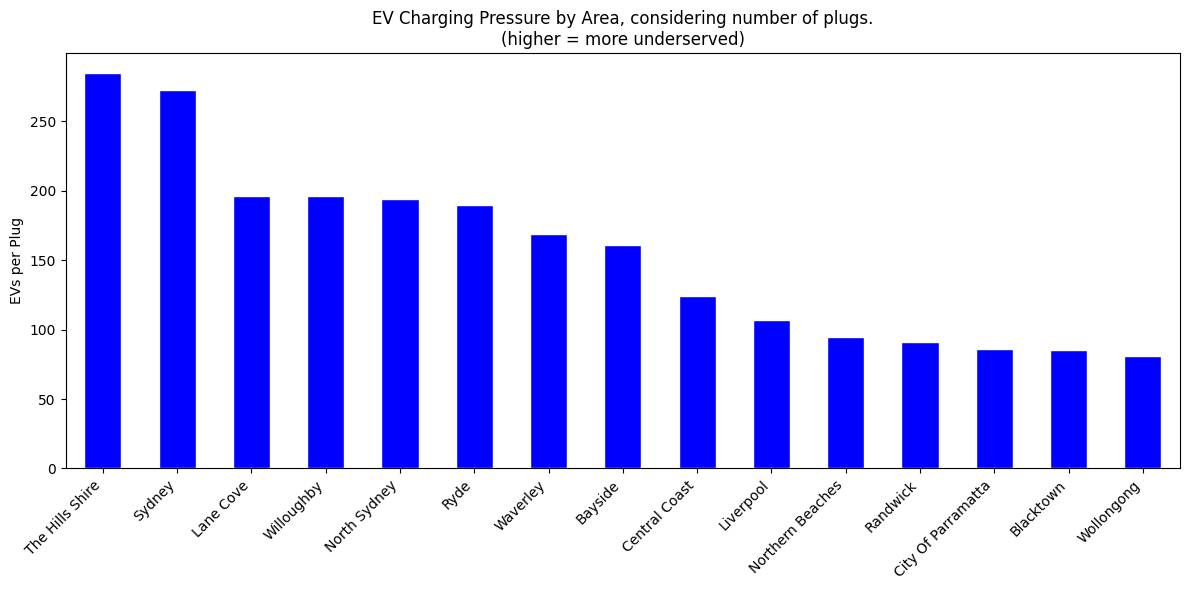

In [ ]:
# EVs per plug
evs_vs_plugs_sorted = evs_vs_plugs.sort_values('evs_per_plug', ascending=False).head(15)

evs_vs_plugs_sorted['evs_per_plug'].plot(kind='bar',
                                          color='blue',
                                          edgecolor='white',
                                          figsize=(12, 6))

plt.title('EV Charging Pressure by Area, considering number of plugs.\n(higher = more underserved)')
plt.xlabel('')
plt.ylabel('EVs per Plug')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The Hills and Sydney is are outliers but they are still the most underserved. Both above 270 Evs per plug. The Hills also needs more chargers. Blacktown has the best ratio. 80 EVs per plug.

Main Story so far:

- There are 3 more than 300,000 registered EVs in NSW, 261 EVs per station, 98 EVs per plug. The infrastrucutre is not keeping up with the EV adoption.
- The wealthy suburbs are EV hotspots but are being underserved (The Hills, Lane Cove, Ryde).
-  While EV adoption is growing rapidly across NSW — particularly in wealthy Sydney suburbs — charging infrastructure is consistently failing to keep pace, with some areas close to have over 1,000 EVs competing for each charging station.



## Socioeconomics Analysis (SEIFA)

SEIFA deciles mean:

Decile 1 = most disadvantaged areas
Decile 10 = most affluent areas
We'll answer two questions:

Questions to answer
Do wealthier areas have more EVs?
Do wealthier areas have more charging stations?

In [ ]:
# Total EVs per SEIFA decile
# We use irsad_decile - this measures both general advantage and disadvantage, looking at both ends of the spectrum.
evs_by_decile = (evs_only.groupby('irsad_decile')['no_vehicles']
                          .sum()
                          .sort_index())  # sort by decile number 1-10

print(evs_by_decile)

irsad_decile
1.0       2327
2.0       3053
3.0       6609
4.0      15494
5.0      19255
6.0      12299
7.0      13164
8.0      21450
9.0      21113
10.0    192196
Name: no_vehicles, dtype: int64


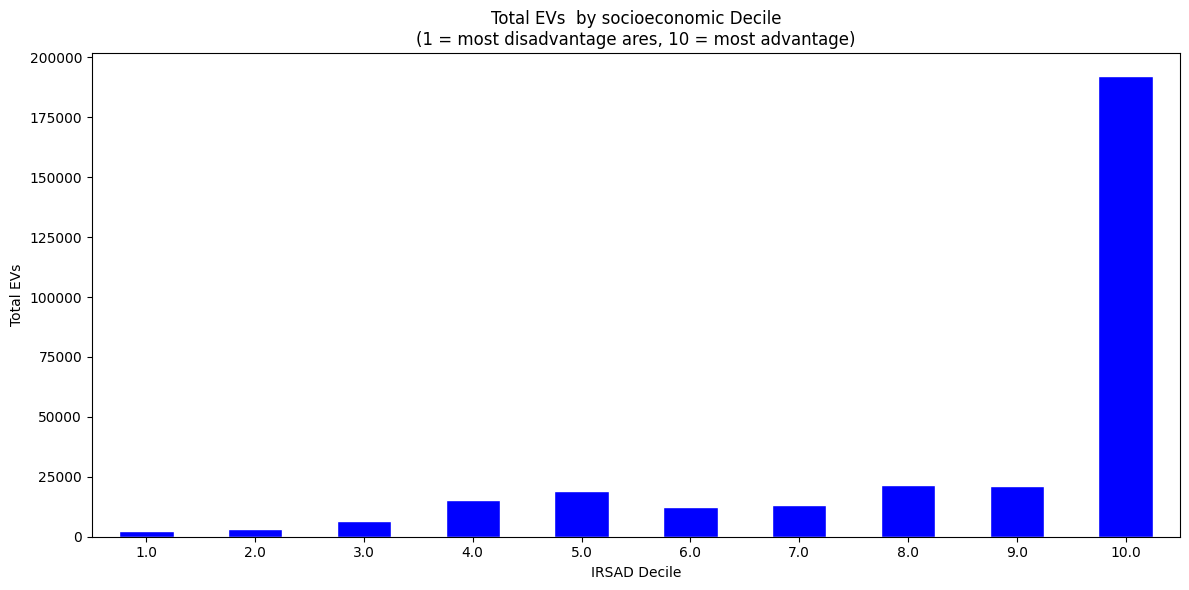

In [ ]:
# Plotting EVs by IRSAD decile
evs_by_decile.plot(
    kind='bar',
    color='blue',
    edgecolor='white',
   figsize=(12, 6))

plt.title('Total EVs  by socioeconomic Decile\n(1 = most disadvantage ares, 10 = most advantage)')
plt.xlabel('IRSAD Decile')
plt.ylabel('Total EVs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

EV ownership is NSW is overwhelmingly concentrated in the most advantages areas.

In [ ]:
stations_by_decile = (active_stations.groupby('irsad_decile')['objectid']
                          .count()
                          .sort_index())  # sort by decile number 1-10

print(stations_by_decile)

irsad_decile
1.0      51
2.0      78
3.0      76
4.0     117
5.0     169
6.0     110
7.0      64
8.0     118
9.0     108
10.0    350
Name: objectid, dtype: int64


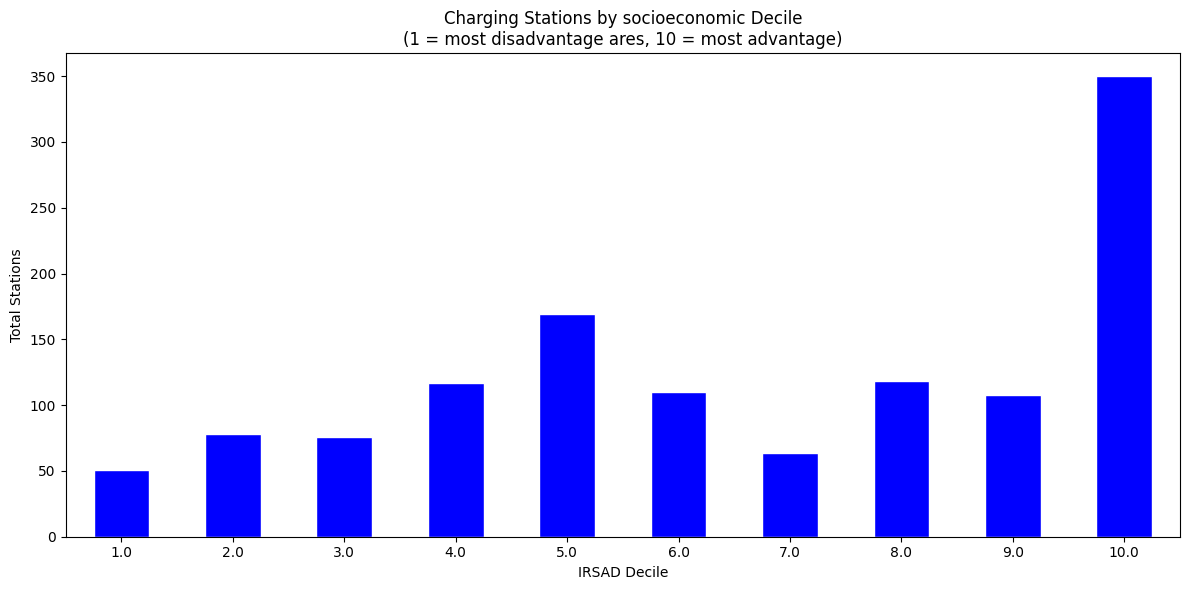

In [ ]:
# Plotting stations by IRSAD decile
stations_by_decile.plot(
    kind='bar',
    color='blue',
    edgecolor='white',
   figsize=(12, 6))

plt.title('Charging Stations by socioeconomic Decile\n(1 = most disadvantage ares, 10 = most advantage)')
plt.xlabel('IRSAD Decile')
plt.ylabel('Total Stations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- Both EVs and stations increase from decile 1 to 10. Wealthier areas have more on both.

- The gap is still big. Decile 10 has 90x more Evs than decile 1 but only 7X more stations. Infrastructure is more evenly than EV ownership.

-  Decile 5 is elevated, confirming that highway towns in decile 5 have many stations. It usually contains many highway corridors and services.

In [ ]:
decile_5_stations = active_stations[active_stations['irsad_decile'] == 5]

# Which LGAs have the most stations in decile 5?
print(decile_5_stations['lganame'].value_counts().head(15))

lganame
Port Macquarie-Hastings    21
Blacktown                  18
Penrith                    15
Cessnock                   14
Bathurst Regional          11
Dubbo Regional             11
Bega Valley                10
Eurobodalla                10
Central Coast               9
Mid-Western Regional        9
Lake Macquarie              8
Maitland                    7
Singleton                   4
Wollongong                  4
Wagga Wagga                 3
Name: count, dtype: int64


Decile 5 has many stations not necause of EV ownership, but because it contains major highways corridors and regional towns where travellers usually need to charge their vehicles on long journeys.

In [ ]:
# Combining EVs and stations by IRSAD decile

eq = pd.DataFrame({
    'Total EVs': evs_by_decile,
    'Total Stations': stations_by_decile
})
print(eq)

              Total EVs  Total Stations
irsad_decile                           
1.0                2327              51
2.0                3053              78
3.0                6609              76
4.0               15494             117
5.0               19255             169
6.0               12299             110
7.0               13164              64
8.0               21450             118
9.0               21113             108
10.0             192196             350


In [ ]:
# EVs per station by decile
eq['evs_per_station'] = (eq['Total EVs'] / eq['Total Stations']).round(0)
print(eq['evs_per_station'])

irsad_decile
1.0      46.0
2.0      39.0
3.0      87.0
4.0     132.0
5.0     114.0
6.0     112.0
7.0     206.0
8.0     182.0
9.0     195.0
10.0    549.0
Name: evs_per_station, dtype: float64


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

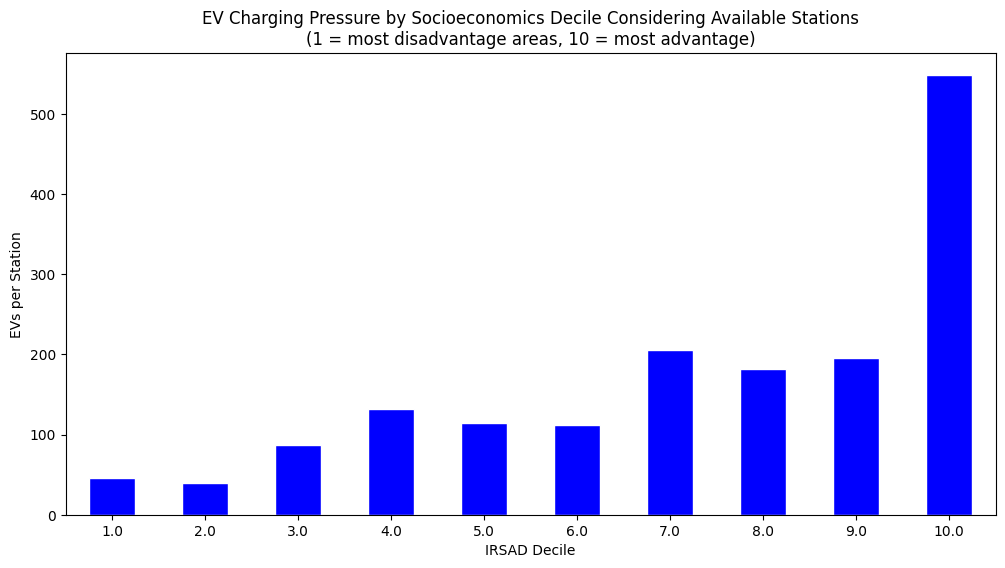

In [ ]:
# EVs per station by decile

eq['evs_per_station'].plot(
    kind='bar',
    color='blue',
    edgecolor='white',
    figsize=(12, 6))

plt.title('EV Charging Pressure by Socioeconomics Decile Considering Available Stations\n(1 = most disadvantage areas, 10 = most advantage)')
plt.xlabel('IRSAD Decile')
plt.ylabel('EVs per Station')
plt.xticks(rotation=0)
plt

The wealthiest areas have 549 EVs competing for every single charging station, 13X more pressure than the most disadvantaged areas. Poor areas have few EVs and few station but station are adequate for demand while wealthy areas have any EVs and many stations but stations are overwhelmed.

In [ ]:
# EV by plug
plugs_by_decile = (active_stations.groupby('irsad_decile')['number_of_plugs']
                          .sum()
                          .sort_index())  # sort by decile number 1-10

print(plugs_by_decile)

irsad_decile
1.0      126
2.0      174
3.0      203
4.0      308
5.0      451
6.0      271
7.0      144
8.0      333
9.0      304
10.0    1010
Name: number_of_plugs, dtype: int64


In [ ]:
eq['Total Plugs'] = plugs_by_decile
eq['evs_per_plug'] = (eq['Total EVs'] / eq['Total Plugs']).round(0)
print(eq['evs_per_plug'])

irsad_decile
1.0      18.0
2.0      18.0
3.0      33.0
4.0      50.0
5.0      43.0
6.0      45.0
7.0      91.0
8.0      64.0
9.0      69.0
10.0    190.0
Name: evs_per_plug, dtype: float64


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

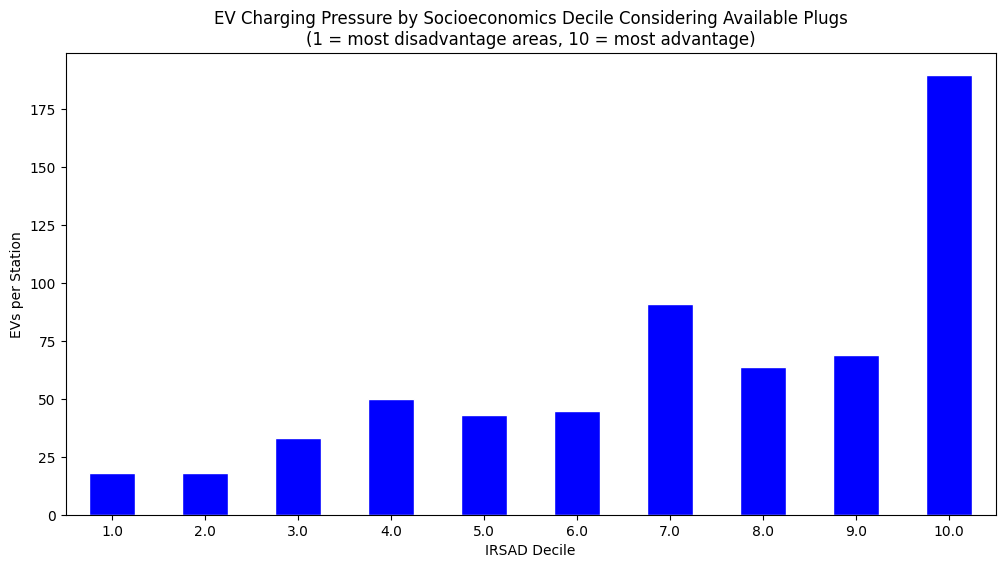

In [ ]:
eq['evs_per_plug'].plot(
    kind='bar',
    color='blue',
    edgecolor='white',
    figsize=(12, 6))

plt.title('EV Charging Pressure by Socioeconomics Decile Considering Available Plugs\n(1 = most disadvantage areas, 10 = most advantage)')
plt.xlabel('IRSAD Decile')
plt.ylabel('EVs per Station')
plt.xticks(rotation=0)
plt

Wealthy areas have 190 EVs per plug but 11x more pressure than disadvantaged areas despite having more charging infrastrucure.

In [ ]:
evs_lga

,total_evs
lganame,
Albury City,1796
Armidale Regional,476
Ballina,1507
Bathurst Regional,1547
Bayside,7888
...,...
Wingecarribee,2129
Wollondilly,103
Wollongong,5239


In [ ]:
stations_lga

,total_stations
lganame,
Albury City,17
Armidale Regional,9
Ballina,9
Balranald,2
Bathurst Regional,11
...,...
Wingecarribee,19
Wollondilly,3
Wollongong,26


In [ ]:
decile_lga = (df.groupby('lganame')['irsad_decile'].mean().round(1).rename('avg_decile'))

In [ ]:
summary = pd.concat([evs_lga, stations_lga, decile_lga], axis =1).dropna()

In [ ]:
print(summary.head(10))

                   total_evs  total_stations  avg_decile
lganame                                                 
Albury City           1796.0              17         5.6
Armidale Regional      476.0               9         5.9
Ballina               1507.0               9         6.6
Bathurst Regional     1547.0              11         5.0
Bayside               7888.0              22         8.7
Bega Valley            948.0              25         4.0
Bellingen               34.0               1         5.0
Blacktown            10991.0              43         6.9
Blayney                 18.0               2         7.9
Blue Mountains        1688.0              22         7.2


In [ ]:
import plotly.express as px

# Creating interactive scatter plot
fig = px.scatter(
    summary,
    x='avg_decile',
    y='total_evs',
    size='total_stations',
    hover_name=summary.index,  # showing LGA name on hover
    title='EV Adoption vs Wealth by Area\n(dot size = number of charging stations)',
    labels={
        'avg_decile'    : 'Average IRSAD Decile (1 = most disadvantaged, 10 = most affluent)',
        'total_evs'     : 'Total EVs',
        'total_stations': 'Total Stations'
    },
    color='total_evs',        # Colouring by number of EVs
    color_continuous_scale='Viridis',
    size_max = 40

)
fig.update_layout( plot_bgcolor='white', paper_bgcolor='white')


fig.show()

In [ ]:
df['state_abb'].value_counts()

,count
state_abb,
NSW,1906160


In [ ]:
print(df[df['state_abb'] != 'NSW']['lganame'].value_counts().head(20))

Series([], Name: count, dtype: int64)


In [ ]:
other_states = df[df['state_abb'] != 'NSW']
print("Charging stations in other states:")
print(other_states.drop_duplicates('objectid')['state_abb'].value_counts())

Charging stations in other states:
Series([], Name: count, dtype: int64)


In [ ]:
print("=== NSW DATASET SUMMARY ===")
print()
print("Total rows:          ", len(df))
print("Total vehicles:      ", df['no_vehicles'].sum())
print("Unique postcodes:    ", df['registered_postcode'].nunique())
print("Unique stations:     ", len(unique_stations))
print("Active stations:     ", len(active_stations))
print("Upcoming stations:   ", len(unique_stations) - len(active_stations))
print("Total EVs:           ", evs_only['no_vehicles'].sum())
print("EV % of all vehicles:", round(evs_only['no_vehicles'].sum() / df['no_vehicles'].sum() * 100, 2), "%")

=== NSW DATASET SUMMARY ===

Total rows:           1906160
Total vehicles:       29774810
Unique postcodes:     371
Unique stations:      1430
Active stations:      1243
Upcoming stations:    187
Total EVs:            306992
EV % of all vehicles: 1.03 %


## Finally Data Cleaning and Conversion of combined dataset into tables that can be used in tableau

In [ ]:
# ============================================================
# FINAL CLEANING BLOCK — RUN AFTER ALL EDA
# Creates clean analysis-ready datasets
# ============================================================

import pandas as pd
import numpy as np

# Make a final copy so original EDA dataframe is preserved
df_final = df.copy()

# ------------------------------------------------------------
# 1. Standardise column names
# ------------------------------------------------------------
df_final.columns = (
    df_final.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

# ------------------------------------------------------------
# 2. Remove duplicate rows
# ------------------------------------------------------------
df_final = df_final.drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# 3. Remove total / summary rows if present
# ------------------------------------------------------------
summary_keywords = ["total", "grand_total", "all"]

for col in df_final.select_dtypes(include="object").columns:
    df_final = df_final[
        ~df_final[col]
        .astype(str)
        .str.lower()
        .str.strip()
        .isin(summary_keywords)
    ]

df_final = df_final.reset_index(drop=True)

# ------------------------------------------------------------
# 4. Clean missing text values
# ------------------------------------------------------------
text_cols = df_final.select_dtypes(include="object").columns

for col in text_cols:
    df_final[col] = (
        df_final[col]
        .astype(str)
        .str.strip()
        .replace(["", "nan", "none", "null", "na", "n/a", "-", "--"], np.nan)
    )

important_text_cols = [
    "operator", "opening_hours", "charger_type",
    "motive_power", "make", "model", "lganame",
    "station_name", "state_abb"
]

for col in important_text_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna("Unknown")

# ------------------------------------------------------------
# 5. Standardise key category values
# ------------------------------------------------------------
if "state_abb" in df_final.columns:
    df_final["state_abb"] = df_final["state_abb"].str.upper()

if "charger_type" in df_final.columns:
    df_final["charger_type"] = df_final["charger_type"].str.upper()
    df_final["charger_type"] = df_final["charger_type"].replace({
        "AC CHARGER": "AC",
        "DC CHARGER": "DC",
        "FAST CHARGER": "DC",
        "UPCOMING": "Upcoming",
        "UNKNOWN": "Unknown"
    })

if "make" in df_final.columns:
    df_final["make"] = df_final["make"].str.title()
    df_final["make"] = df_final["make"].replace({
        "Bmw": "BMW",
        "Byd": "BYD",
        "Mg": "MG",
        "Kia": "KIA",
        "Ldv": "LDV",
        "Vw": "VW",
        "Gmc": "GMC"
    })

if "operator" in df_final.columns:
    df_final["operator"] = df_final["operator"].str.title()
    df_final["operator"] = df_final["operator"].replace({
        "Tesla Destination": "Tesla",
        "Tesla Supercharge": "Tesla",
        "Tesla Supercharger": "Tesla"
    })

if "motive_power" in df_final.columns:
    df_final["motive_power"] = df_final["motive_power"].str.strip()
    df_final["motive_power"] = df_final["motive_power"].replace({
        "Battery / Fuel-Cell Electric": "Battery/Fuel-Cell Electric",
        "Battery/Fuel Cell Electric": "Battery/Fuel-Cell Electric",
        "Battery Electric": "Battery/Fuel-Cell Electric"
    })

# ------------------------------------------------------------
# 6. Convert numeric columns safely
# ------------------------------------------------------------
possible_numeric_cols = [
    "no_vehicles", "number_of_plugs", "charger_rating",
    "latitude", "longitude", "population",
    "irsd_score", "irsd_decile",
    "irsad_score", "irsad_decile",
    "ier_score", "ier_decile"
]

for col in possible_numeric_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

# ------------------------------------------------------------
# 7. Keep postcode columns as strings
# ------------------------------------------------------------
postcode_cols = [
    "registered_postcode",
    "postcode",
    "poa_code",
    "2021_postal_area_poa_code"
]

for col in postcode_cols:
    if col in df_final.columns:
        df_final[col] = (
            df_final[col]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
        )

# ------------------------------------------------------------
# 8. Keep NSW only
# ------------------------------------------------------------
if "state_abb" in df_final.columns:
    df_final = df_final[df_final["state_abb"] == "NSW"].copy()

# ------------------------------------------------------------
# 9. Coordinate quality flag
# NSW approximate latitude/longitude range
# ------------------------------------------------------------
if {"latitude", "longitude"}.issubset(df_final.columns):
    df_final["bad_coordinates"] = (
        df_final["latitude"].isna() |
        df_final["longitude"].isna() |
        (df_final["latitude"] < -38) |
        (df_final["latitude"] > -28) |
        (df_final["longitude"] < 140) |
        (df_final["longitude"] > 154)
    )
else:
    df_final["bad_coordinates"] = np.nan

df_map_ready = df_final[df_final["bad_coordinates"] == False].copy()

# ------------------------------------------------------------
# 10. Create active charging station dataset
# ------------------------------------------------------------
if "charger_type" in df_final.columns:
    station_df = df_final[
        df_final["charger_type"].isin(["AC", "DC", "Unknown"])
    ].copy()
else:
    station_df = df_final.copy()

station_subset_cols = [
    col for col in ["station_name", "latitude", "longitude", "operator"]
    if col in station_df.columns
]

if len(station_subset_cols) > 0:
    station_df = station_df.drop_duplicates(subset=station_subset_cols)
else:
    station_df = station_df.drop_duplicates()

active_station_df = station_df.copy()

if "charger_type" in active_station_df.columns:
    active_station_df = active_station_df[
        active_station_df["charger_type"] != "Upcoming"
    ].copy()

# ------------------------------------------------------------
# 11. Create EV-only vehicle dataset
# ------------------------------------------------------------
if "motive_power" in df_final.columns:
    ev_df = df_final[
        df_final["motive_power"]
        .astype(str)
        .str.contains("Electric", case=False, na=False)
    ].copy()
else:
    ev_df = df_final.copy()

# ------------------------------------------------------------
# 12. Outlier flags for analysis
# ------------------------------------------------------------
if "no_vehicles" in df_final.columns:
    q1 = df_final["no_vehicles"].quantile(0.25)
    q3 = df_final["no_vehicles"].quantile(0.75)
    iqr = q3 - q1

    df_final["vehicle_outlier_flag"] = (
        (df_final["no_vehicles"] < q1 - 1.5 * iqr) |
        (df_final["no_vehicles"] > q3 + 1.5 * iqr)
    )

if "number_of_plugs" in df_final.columns:
    df_final["plug_issue_flag"] = (
        df_final["number_of_plugs"].isna() |
        (df_final["number_of_plugs"] <= 0)
    )

# ------------------------------------------------------------
# 13. Create LGA-level analysis table
# ------------------------------------------------------------
if "lganame" in df_final.columns:

    if "no_vehicles" in ev_df.columns:
        evs_lga = (
            ev_df.groupby("lganame")["no_vehicles"]
            .sum()
            .rename("total_evs")
        )
    else:
        evs_lga = pd.Series(dtype=float, name="total_evs")

    if "station_name" in active_station_df.columns:
        stations_lga = (
            active_station_df.groupby("lganame")["station_name"]
            .nunique()
            .rename("total_stations")
        )
    else:
        stations_lga = pd.Series(dtype=float, name="total_stations")

    if "number_of_plugs" in active_station_df.columns:
        plugs_lga = (
            active_station_df.groupby("lganame")["number_of_plugs"]
            .sum()
            .rename("total_plugs")
        )
    else:
        plugs_lga = pd.Series(dtype=float, name="total_plugs")

    if "irsad_decile" in df_final.columns:
        seifa_lga = (
            df_final.groupby("lganame")["irsad_decile"]
            .mean()
            .round(2)
            .rename("avg_irsad_decile")
        )
    else:
        seifa_lga = pd.Series(dtype=float, name="avg_irsad_decile")

    analysis_lga = pd.concat(
        [evs_lga, stations_lga, plugs_lga, seifa_lga],
        axis=1
    ).fillna(0).reset_index()

    analysis_lga["evs_per_station"] = (
        analysis_lga["total_evs"] /
        analysis_lga["total_stations"].replace(0, np.nan)
    ).round(2)

    analysis_lga["evs_per_plug"] = (
        analysis_lga["total_evs"] /
        analysis_lga["total_plugs"].replace(0, np.nan)
    ).round(2)

else:
    analysis_lga = pd.DataFrame()

# ------------------------------------------------------------
# 14. Export cleaned files
# ------------------------------------------------------------
df_final.to_csv("cleaned_full_dataset.csv", index=False)
df_map_ready.to_csv("map_ready_dataset.csv", index=False)
station_df.to_csv("station_level_dataset.csv", index=False)
active_station_df.to_csv("active_station_dataset.csv", index=False)
ev_df.to_csv("ev_only_dataset.csv", index=False)
analysis_lga.to_csv("lga_analysis_dataset.csv", index=False)

# ------------------------------------------------------------
# 15. Final summary
# ------------------------------------------------------------
print("Cleaning complete.")
print("Full cleaned dataset:", df_final.shape)
print("Map-ready dataset:", df_map_ready.shape)
print("Station-level dataset:", station_df.shape)
print("Active station dataset:", active_station_df.shape)
print("EV-only dataset:", ev_df.shape)
print("LGA analysis dataset:", analysis_lga.shape)

display(analysis_lga.head())

Cleaning complete.
Full cleaned dataset: (1906160, 34)
Map-ready dataset: (1906160, 32)
Station-level dataset: (1234, 32)
Active station dataset: (1234, 32)
EV-only dataset: (108763, 32)
LGA analysis dataset: (119, 7)


,lganame,total_evs,total_stations,total_plugs,avg_irsad_decile,evs_per_station,evs_per_plug
0,Albury City,10014,15,48,5.58,667.60,208.62
1,Armidale Regional,3593,9,20,5.92,399.22,179.65
2,Ballina,5856,9,30,6.59,650.67,195.20
3,Balranald,15,2,4,3.53,7.50,3.75
4,Bathurst Regional,9178,11,23,5.00,834.36,399.04


In [ ]:
print("Cleaned Dataset")
display(df_final.head())
print("Map Ready Dataset")
display(df_map_ready.head())
print("Station Level Dataset")
display(station_df.head())
print("Active Station Dataset")
display(active_station_df.head())
print("EV Only Dataset")
display(ev_df.head())
print("LGA Analysis Dataset")
display(analysis_lga.head())

Cleaned Dataset


,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population,bad_coordinates,vehicle_outlier_flag,plug_issue_flag
0,546,Darling Quarter First Parking,"1/11 Harbour St, Sydney NSW 2000, Australia",Unknown,Unknown,2.0,2,AC,NaN,0.0,-33.874400,151.202559,Sydney,2000.0,Passenger Vehicles,NSW,2000,Petrol,BMW,230,7,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False,False,False
1,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF-R6,4,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False,False,False
2,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF155,0,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False,False,False
3,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF320,3,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False,False,False
4,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZR-R7,3,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False,False,False


Map Ready Dataset


,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population,bad_coordinates
0,546,Darling Quarter First Parking,"1/11 Harbour St, Sydney NSW 2000, Australia",Unknown,Unknown,2.0,2,AC,NaN,0.0,-33.874400,151.202559,Sydney,2000.0,Passenger Vehicles,NSW,2000,Petrol,BMW,230,7,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
1,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF-R6,4,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
2,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF155,0,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
3,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF320,3,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
4,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZR-R7,3,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False


Station Level Dataset


...

,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population,bad_coordinates
0,546,Darling Quarter First Parking,"1/11 Harbour St, Sydney NSW 2000, Australia",Unknown,Unknown,2.0,2,AC,NaN,0.0,-33.874400,151.202559,Sydney,2000.0,Passenger Vehicles,NSW,2000,Petrol,BMW,230,7,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
1,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Yamaha,YZF-R6,4,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
10,588,Grosvenor Place - Wilson Parking (7 Essex St),"225 George Street, The Rocks NSW 2000, Australia",Monday to Friday 6am-8pm,Saascharge International Gmbh,2.0,4,AC,22.0,0.0,-33.862895,151.207252,Sydney,2000.0,Passenger Vehicles,NSW,2000,Petrol,Alfa Romeo,147,0,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
1622,584,The Amora Hotel Jamison Sydney,"11 Jamison St, Sydney, Australia, NSW 2000",Open 24/7,Tesla,2.0,2,AC,22.0,2.0,-33.864331,151.206069,Sydney,2000.0,Motorcycles,NSW,2000,Petrol,Suzuki,SFV650,3,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
3278,590,Intercontinental Hotel,117 Macquarie St Sydney NSW 2000,Unknown,"Tesla Destination, Chargefox",2.0,3,AC,22.0,2.0,-33.862807,151.212369,Sydney,2000.0,Passenger Vehicles,NSW,2000,Petrol,Chrysler,VOYAGER,3,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False


EV Only Dataset


,objectid,station_name,station_address,opening_hours,operator,number_of_stations,number_of_plugs,charger_type,charger_rating,tesla_fast,latitude,longitude,lganame,pcode,vehicle_type,state_abb,registered_postcode,motive_power,make,model,no_vehicles,poa_code,irsd_score,irsd_decile,irsad_score,irsad_decile,ier_score,ier_decile,ieo_score,ieo_decile,population,bad_coordinates
7,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Battery/Fuel-Cell Electric,BMW,CE04,0,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
8,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Battery/Fuel-Cell Electric,Fonzarelli,UNKNOWN,5,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
9,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Motorcycles,NSW,2000,Battery/Fuel-Cell Electric,Fonzarelli Bikes,UNKNOWN,0,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
567,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Light Rigid Trucks,NSW,2000,Hybrid Electric,Hino,300 SERIES,0,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False
568,587,Origin Energy Barangaroo Office,"100 Barangaroo Ave, Barangaroo NSW 2000, Austr...",Unknown,Unknown,1.0,1,AC,NaN,0.0,-33.863851,151.202139,Sydney,2000.0,Light Rigid Trucks,NSW,2000,Battery/Fuel-Cell Electric,Foton,IBLUE,30,2000,973.065405,4.0,1106.973326,10.0,804.156377,1.0,1142.271453,10.0,27936.0,False


LGA Analysis Dataset


,lganame,total_evs,total_stations,total_plugs,avg_irsad_decile,evs_per_station,evs_per_plug
0,Albury City,10014,15,48,5.58,667.60,208.62
1,Armidale Regional,3593,9,20,5.92,399.22,179.65
2,Ballina,5856,9,30,6.59,650.67,195.20
3,Balranald,15,2,4,3.53,7.50,3.75
4,Bathurst Regional,9178,11,23,5.00,834.36,399.04
